# Import libs

In [1]:
from regime_identification.Features.features import get_log
from regime_identification.Splitting.split import find_split, add_f
from regime_identification.Features.regimes import get_corrM_roll, get_long_corrM, expanding_norm, get_pca, scree_pca, plot_clusters

import pandas as pd
import numpy as np
import sklearn as skl
from sklearn.cluster import MiniBatchKMeans
from datetime import datetime, timedelta, date
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm # Loading bars

# Data retrieval

In [2]:
# Update ETF data
# %run update_data.py

In [3]:
# Importing unprocessed data
from data_script import config, exm, etfs

Loading data...
ETFs


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 44.36it/s]

Extramarket

Done!


# Data processing

In [4]:
# Close-Close log returns for ETF data
for i in tqdm(etfs):
    etfs[i]["Ticker"] = i # Used later for ID
    etfs[i]["logret"] = get_log(etfs[i]["Close"])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 790.60it/s]


In [5]:
# Extramarket data
'''
Extramarket data is tricky, as some features are to be standardized,
while others should be the logarithmic returns (adjusted for inflation or otherwise)
Additionally, standardization should be done in expanding-window manner for test data.
'''

# Standardize
stdize = ["BLP", "FF", "pe_ratio"] 

# Logret & adjust for inflation
commodities = ["electricity_kwh", "gasoline_gallon", 
               "household-gas_therm", "housing", "gold"]

# Unadjusted logret
fx = ["fx_JPUS", "fx_USEU", "fx_USUK",
      "VIX", # Not really an FX, but should be processed the same way
     ]

exm_p = exm.copy() # exm_p = ex(tra)m(arket) processed data

In [6]:
# FX processing
for i in fx:
    exm_p[i] = get_log(exm[i].dropna(how = "any"))

In [7]:
# Commodities processing
log_inflation = get_log(exm["inflation_cpi"].dropna(how = "any").astype(float))
exm_p["log_inflation"] = log_inflation

for i in commodities:
    exm_p[i] = get_log(exm[i].dropna(how = "any")) - log_inflation

Expanding-window standardization for `stdize` happens later (together with all other features)

## Correlation

The recent degree of correlation between features can be indicative of a regime. Thus, we calculate a rolling correlation matrix between all features to later be fed into the model.

In [9]:
'''
window = config["CORR_WINDOW"]

corrM = get_corrM_roll(exm_p, window)
long_corrM = get_long_corrM(corrM)
'''

'\nwindow = config["CORR_WINDOW"]\n\ncorrM = get_corrM_roll(exm_p, window)\nlong_corrM = get_long_corrM(corrM)\n'

## Splitting into test & training

To simulate a live environment, we have to split the data into training (seen/future) and test (unseen/future). Training data will be processed as a single entity while test data processing uses an expanding window to ensure only past data is used.

The first of january 2019 is chosen as the split date to allow a variety of regimes to be identified in the test data (most notably, the 2020 COVID-19 recession)

In [10]:
split_date = pd.to_datetime(date(2019, 1, 1))

## Forward-filling

Forward filling is limited to 1 calendar month at most.

In [11]:
exm_p.shape

(21901, 18)

In [12]:
# Forward-fill to max 1 month
def ffill_month(df, months = 1):
    df = df.sort_index()

    # empty index with every missing DAILY date
    full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")

    result = df.reindex(full_index).ffill()

    # Most recent original observation for each date
    last_obs = pd.Series(
        df.index,
        index=df.index
    ).reindex(full_index).ffill()

    # Only keep if within one calendar month
    valid = full_index <= last_obs + pd.DateOffset(months=months)

    result = result.where(valid)

    return result

exm_p = ffill_month(exm_p)

In [13]:
exm_p.shape

(280760, 18)

## Standardization

Unsupervised learning (PCA & clustering) algorithms generally require standardized data.

The training data is standardized by the entirety of the available data. The test data is standardized in an expanding fashion (which includes training data).

In [14]:
exm_p_norm = expanding_norm(exm_p, norm_start = split_date)

In [15]:
exm_p_norm.describe()

,electricity_kwh,gasoline_gallon,household-gas_therm,housing,inflation_cpi,BLP,FF,pe_ratio,treasury_yield_3mo,treasury_yield_10y,treasury_yield_curve,GDP,fx_JPUS,fx_USEU,fx_USUK,gold,VIX,log_inflation
count,17452.000000,17452.000000,17452.000000,17452.000000,17482.000000,11212.000000,11212.000000,56867.000000,16447.000000,16447.000000,16447.000000,23629.000000,20339.000000,10112.000000,20339.000000,17452.000000,13401.000000,17452.000000
mean,0.010558,0.007460,0.013038,0.017427,0.320447,0.061300,0.050325,0.058265,-0.052914,-0.139384,0.095615,-0.119790,0.002669,0.002530,0.004164,0.014256,-0.005182,0.010967
std,0.938319,1.027419,1.006306,1.000332,1.176049,0.986466,0.980463,1.013352,0.955715,0.980526,1.079544,1.008299,0.989533,0.933405,0.990361,0.950339,1.040734,0.993590
min,-3.294908,-7.496381,-4.685770,-3.950987,-1.915361,-1.020586,-1.060336,-1.240932,-1.239794,-1.678783,-1.704487,-1.915061,-14.737607,-4.785343,-13.628112,-4.344356,-6.472573,-6.545991
25%,-0.354361,-0.422160,-0.435434,-0.546080,-0.638306,-0.992807,-0.982849,-0.491947,-0.950740,-0.932270,-0.971357,-0.782072,-0.436025,-0.513506,-0.479974,-0.456904,-0.593533,-0.479357
50%,-0.058271,-0.045522,-0.033775,-0.056320,0.287995,-0.201294,-0.247062,-0.077587,-0.015379,-0.346083,0.421904,-0.270973,0.000858,-0.005835,0.024853,-0.054150,-0.076626,-0.081132
75%,0.361616,0.472255,0.442920,0.503497,1.359017,1.179971,1.114965,0.341270,0.519134,0.422512,0.909299,0.466492,0.494020,0.509823,0.511320,0.477089,0.496146,0.400673
max,4.001909,4.276926,5.818239,7.320843,2.249202,1.868959,2.433714,12.864508,3.990864,3.252574,2.752432,3.357216,9.701009,7.381019,7.693366,8.289380,11.829523,3.638383


In [16]:
# drop inflation CPI because not informative
exm_p_norm = exm_p_norm.drop("inflation_cpi", axis = 1)

## PCA & residualization

To ensure that high degrees of correlation between features do not cause over-emphasization of underlying macro-economic events, PCA is used to approximate & isolate these grander events. Residualization is then applied to isolate the effects of individual features. 

In [17]:
# Can't have NAs in PCA, so drop them
exm_p_norm = exm_p_norm.dropna(how = "any")
# Can only fit PCA on training data
training = exm_p_norm[exm_p_norm.index < split_date]

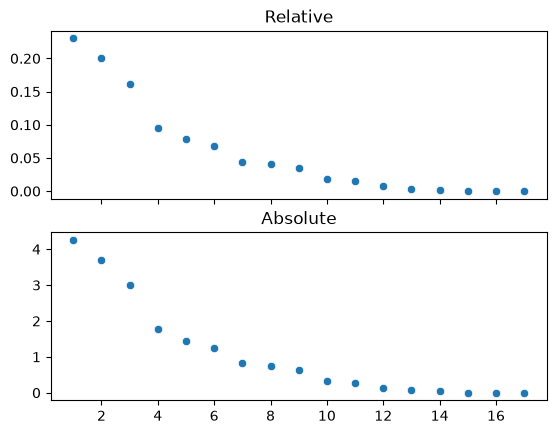

In [18]:
# Initial PCA without limits
pca, training_pcs = get_pca(training)
scree_pca(pca)

It seems our elbow is at around 4 PCs. Keep 5 to be sure.

In [23]:
# PCA restricted to most explanatory PCs
pca, training_pcs = get_pca(training, n_components = 5)

pcs = pd.DataFrame(pca.transform(exm_p_norm), index = exm_p_norm.index)
pcs.columns = [f"PC{i}" for i in pcs.columns] # Rename for clarity

In [24]:
# Residualize features
residuals = exm_p_norm - pca.inverse_transform(pcs)

In [25]:
residuals.describe()

,electricity_kwh,gasoline_gallon,household-gas_therm,housing,BLP,FF,pe_ratio,treasury_yield_3mo,treasury_yield_10y,treasury_yield_curve,GDP,fx_JPUS,fx_USEU,fx_USUK,gold,VIX,log_inflation
count,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000
mean,0.003195,-0.020812,-0.011736,0.026757,-0.031034,-0.043351,0.011542,0.003187,-0.082954,0.115633,-0.093846,0.002946,-0.002532,0.003322,0.000785,-0.007314,0.066248
std,0.800772,0.409809,0.077456,0.364894,0.131734,0.135231,0.038354,0.075866,0.261999,0.348981,0.282610,0.827304,0.430493,0.523229,0.765739,1.076935,0.342997
min,-2.420099,-1.214403,-0.284739,-1.075793,-0.591142,-0.611342,-0.149393,-0.399224,-0.917550,-0.745732,-0.982704,-8.934191,-2.385753,-8.236868,-3.104291,-6.528634,-1.093643
25%,-0.346844,-0.307508,-0.057879,-0.247347,-0.107087,-0.118148,-0.016114,-0.028012,-0.250592,-0.114694,-0.273954,-0.404888,-0.247229,-0.256273,-0.494565,-0.619411,-0.129514
50%,-0.082825,-0.040305,-0.010979,0.000857,-0.013573,-0.014985,0.011633,0.012613,-0.093948,0.026589,-0.107017,0.005817,0.000246,0.015499,-0.054256,-0.095873,0.053317
75%,0.292242,0.235216,0.035549,0.277325,0.071328,0.057573,0.037738,0.049224,0.101461,0.230430,0.103479,0.415920,0.239045,0.272954,0.473010,0.498784,0.214637
max,2.849935,1.231859,0.336929,1.187516,0.422402,0.731071,0.162613,0.219409,0.535252,1.946299,0.571726,5.594055,2.233901,3.298087,3.470414,11.846892,1.348940


# Identify regime clusters

In [36]:
# number of clusters
n_clusters = 4
# Combine PCs and residuals
full = pcs.join(residuals)
# Can only fit on training data
training = full[full.index < split_date]

km = MiniBatchKMeans(n_clusters = n_clusters)
km = km.fit(training)

clusters = pd.DataFrame(km.predict(full), index = full.index)

full["cluster"] = clusters

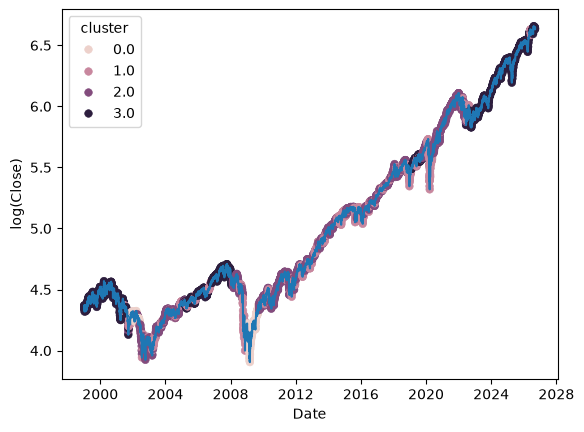

In [37]:
plot_clusters(clusters)

## Best and worst performers per phase

We can rate the per-regime performance of asset classes via the next-day-closing returns of a representative ETF. 

There are many metrics to rate stock performance by, such as raw returns or sharpe ratio. Here, stocks are **rated by sortino ratio**, where returns are penalized for their downside volatility only (as opposed to bidirectional volatility with sharpe ratio). This is done in the interest of minimizing risk for leveraged positions. 

Note that the worst performers (to be shorted) should also have the lowest upside volatility (hence the altered "inverse" sortino formula).

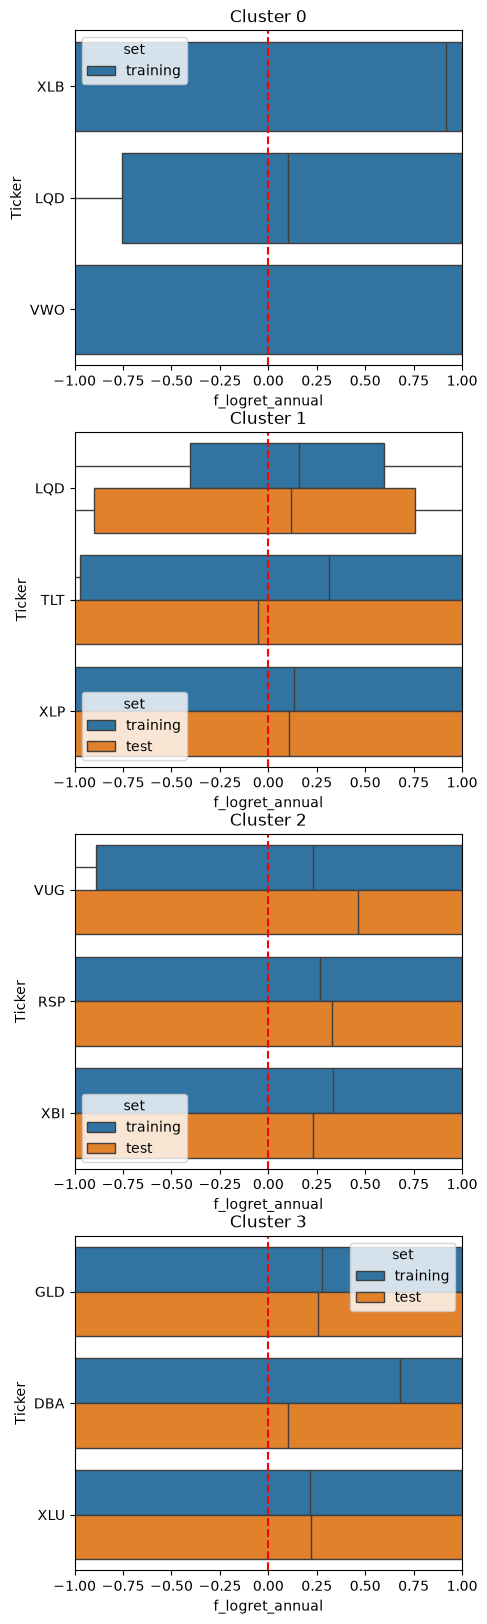

In [44]:
fig, ax = plt.subplots(n_clusters, 1, figsize = (5, 20))

df = pd.concat(etfs.values()).join(full) # values() to avoid redundant multiindex

# Annualize logret for readability
df["logret_annual"] = df["logret"] * 252
# Next-day returns
df["f_logret_annual"] = df["logret_annual"].shift(-1) 

df["set"] = None
df.loc[df.index < split_date, "set"] = "training"
# print(np.max(df.loc[df.index < split_date_].index))
df.loc[df.index > split_date, "set"] = "test"
# print(np.max(df.loc[df.index > split_date_].index))
df = df[df["Ticker"] != "^VIX"]

'''
axis = 0
for i in ["training", "test"]:
    sns.boxplot(data = df[df["set"] == i].reset_index(), x = 'f_1d_Close_logret', y = "Ticker", 
                hue = "cluster", # orient = "v",
                ax = ax[axis],
               ).set_title(i)
    ax[axis].set_xlim(-0.10, 0.10)
    ax[axis].axvline(x = 0, color = "red", linestyle = "--")
    axis += 1
    
'''

n_tickers = 3 # How many tickers to display for each side
axis = 0
for i in range(n_clusters):
    top_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: np.sum(x) / np.std(x[x < 0])).nlargest(n_tickers, keep = "first").index 
    top_tickers_sortino = list(top_tickers_sortino)

    worst_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: -np.sum(x) / np.std(x[x > 0])).nlargest(n_tickers, keep = "first").index 
    worst_tickers_sortino = list(worst_tickers_sortino)

    for j in [top_tickers_sortino]:
        sns.boxplot(data = df[(df["cluster"] == i) & (df["Ticker"].isin(j))].reset_index(), x = 'f_logret_annual', y = "Ticker", 
                    hue = "set", # orient = "v",
                    ax = ax[axis],
                   ).set_title(f"Cluster {i}")
        ax[axis].set_xlim(-1, 1)
        ax[axis].axvline(x = 0, color = "red", linestyle = "--")

    
    axis += 1
        
plt.show()
plt.close()

# Backtesting